# Bioreactor simulation, state estimation and control
Welcome to this project. You can read the readme for more general information. This file will show the different experiments ran with the simulation as well as explanations on how the simulation and state estimations work (control hasn't been implemented yet)


The bioreactors simulated in this project are fed-batch, without any removal of the mixture. We keep track of four variables for the state of the system: The biomass concentration (X), the substrate concentration (S), the volume (V) and the waste concentration (W)

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model.bioreactor import ideal_Bioreactor, real_Bioreactor
from estimation.ekf import EKF
from parameters import Parameters
from control.mpc import MPC
from ipywidgets import *

Retrieving default parameters for the simulations. I will later use some alternative parameters for some simulations. If you want to use this, you can go to parameters.py and make changes to easily keep track of the parameters

In [2]:
params = Parameters()
bioreactor_params = params.get_bioreactor_params()
ekf_params = params.get_ekf_params()
grid_params = params.get_grid_params()

time_steps = 24000 # number of time steps to simulate (24 hours)
dt = 0.001 # hours



Example of feed rate function. I used sinusoidal here.

In [3]:
def F_sine(t):
    return  0.1 * abs(np.sin(2 * np.pi * t / 24)) # example feed rate function (sinusoidal)

Initalizing ideal bioreactor and ekf. 
The ideal bioreactor functions on a simple assumption : The bioreactor is perfectly mixed. Therefore, I used a system of ODEs to update the state of the ideal bioreactor.

$
\mu(S,W) = \mu _{max} \frac{S}{K_S + S} \frac{K_W}{K_W + W} \\ 
\frac{dX}{dt} = \mu(S,W)X - \frac{F}{V}X \\
\frac{dS}{dt} = -\frac{1}{Y}\mu(S,W)X + \frac{F}{V}(S_in - S)\\
\frac{dW}{dt} = K_W X + K_{W growth} \mu(S,W) X - \frac{F}{V}W\\
\frac{dV}{dt} = F
$

I also used an extended kalman filter since the update is non linear (basically it just makes it linear). I used it to try to estimate the states of the system based on the measurements. We measure the volume at every time step, the biomass every 10 timesteps and the substrate concentration every 20 timesteps, all with more or less error in the measurement represented by a normally distributed noise

In [4]:
bioreactor = ideal_Bioreactor(bioreactor_params)
ekf = EKF(bioreactor, ekf_params)


In [5]:
true_states = []
estimated_states = []
true_states.append(bioreactor.state.copy())
estimated_states.append(ekf.state.copy())
for t in range(time_steps):
    F_t = F_sine(t * dt)
    true_states.append(bioreactor.update(F_t, dt))
    estimated_states.append(ekf.step(F_t,t, dt))
true_states = np.array(true_states)
estimated_states = np.array(estimated_states)


Plotting true states vs estimated states and the error of the EKF. The EKF manages to estimate the state of the system pretty well, which isn't really surprising considering the model it has is literally perfect, since I use the same model for the simulation

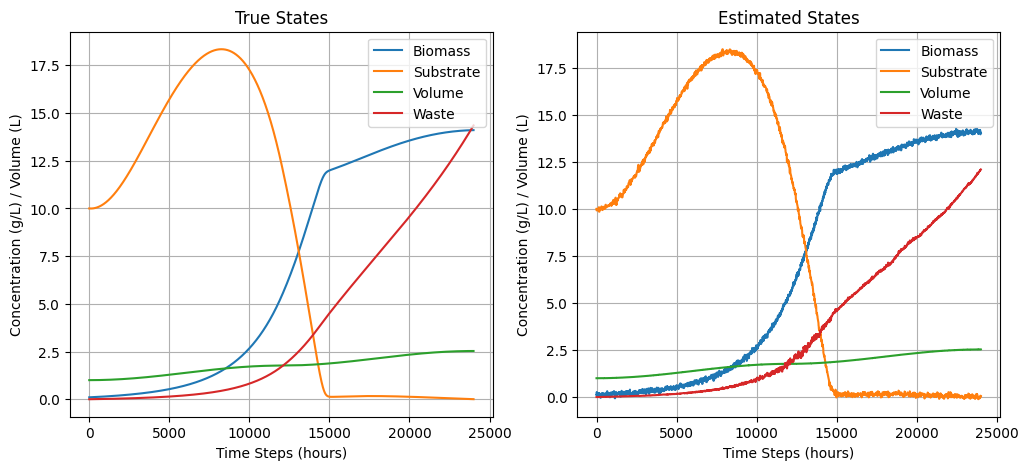

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('True States')
plt.subplot(1, 2, 2)
plt.plot(estimated_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Estimated States')
plt.legend()

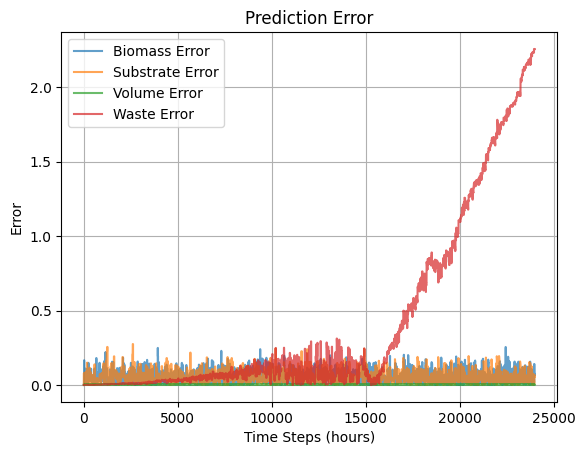

In [7]:
error = np.sqrt((true_states - estimated_states) ** 2)
plt.plot(error, label=['Biomass Error', 'Substrate Error', 'Volume Error', 'Waste Error'], alpha=0.7)
plt.xlabel('Time Steps (hours)')
plt.ylabel('Error')
plt.grid()
plt.title('Prediction Error')
plt.legend()

Text(0.5, 1.0, 'Mean Prediction Error vs. Measurement Uncertainty')

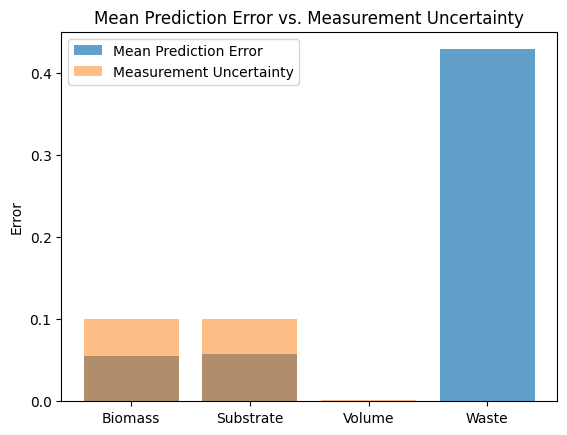

In [8]:
mean_errors = np.mean(error, axis=0)
measurement_uncertainty = [ekf_params['R_x'], ekf_params['R_s'], ekf_params['R_v'], 0]
plt.bar(['Biomass', 'Substrate', 'Volume', 'Waste'], mean_errors, alpha=0.7, label='Mean Prediction Error')
plt.bar(['Biomass', 'Substrate', 'Volume', 'Waste'], measurement_uncertainty, alpha=0.5, label='Measurement Uncertainty')
plt.legend()
plt.ylabel('Error')
plt.title('Mean Prediction Error vs. Measurement Uncertainty')

The non-ideal bioreactor does not make the perfect homogeneity assumption. Instead, we simulate a 2D grid representing local points in the bioreactor (2D made the most sense, you can imagine each cell as a column that's being filled up)
I wanted to keep this simulation cheap, so I'm not solving the full navier stokes equation. CFD can do that better anyway. So we assume that the volume is a scalar, meaning the volume instantly evens out througout the bioreactor. Note that that's only true for the volume, not the concentration gradient. The substrate will have to diffuse independently from the volume. 

In this model, we simulate the diffusion of the concentrations within the bioreactor, but also with stirring and turbulence. The stirring is modeled using a velocity field, and turbulence is modeled as random temporary diffusion points (I tried a few other stuff, but this gave the best results and is the easiest to compute)

The PDEs for the spacial bioreactor are

$
\frac{\partial X}{\partial t} = -\nabla \cdot (uX) + \mu(S,W)X + D_t \nabla^2 X \\
\frac{\partial S}{\partial t} = -\nabla \cdot (uS) + \frac{F}{V}S_{in} \delta_{in} -\frac{1}{Y} \mu(S,W)X + (D_S + D_{turbulence}) \nabla^2 S \\
\frac{\partial W}{\partial t} = -\nabla \cdot (uW) + K_W X + K_{W growth} \mu(S,W) X + (D_W + D_{turbulence}) \nabla^2 W \\
\frac{dV}{dt} = F\\
$
The gradients are then updated with a dilution factor $ \frac{V}{V+dV} $

The EKF still uses the first ideal model, therefore we investigate whether it is still able to estimate the states of the system

In [9]:
real_bioreactor = real_Bioreactor(bioreactor_params, grid_params)
ekf = EKF(real_bioreactor, ekf_params)

In [10]:
true_states_real = []
X_grids = []
S_grids = []
estimated_states_real = []
true_states_real.append(real_bioreactor.state.copy())
X_grids.append(real_bioreactor.X_grid.copy())
S_grids.append(real_bioreactor.S_grid.copy())
estimated_states_real.append(ekf.state.copy())
for t in range(time_steps):
    F = F_sine(t * dt)
    real_bioreactor.update(F, dt)
    estimated_states_real.append(ekf.step(F,t, dt))
    true_states_real.append(real_bioreactor.state.copy())
    X_grids.append(real_bioreactor.X_grid.copy())
    S_grids.append(real_bioreactor.S_grid.copy())
true_states_real = np.array(true_states_real)
estimated_states_real = np.array(estimated_states_real)
X_grids = np.array(X_grids)
S_grids = np.array(S_grids)
history = {'biomass': X_grids, 'substrate': S_grids}

The animation shows the local concentrations

In [11]:
def plotter(timestep, history):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(history['biomass'][timestep], cmap='inferno')
    plt.title(f'Biomass at Timestep {timestep}')
    plt.colorbar(label='Biomass Concentration')
    plt.subplot(1, 2, 2)
    plt.imshow(history['substrate'][timestep], cmap='inferno')
    plt.title(f'Substrate at Timestep {timestep}')
    plt.colorbar(label='Substrate Concentration')
    plt.show()

interactive(plotter, timestep = Play(min=0, max=time_steps, value=0, interval=20),
             history=fixed(history))

interactive(children=(Play(value=0, description='timestep', interval=20, max=24000), Output()), _dom_classes=(…

Comparing the real and ideal bioreactor shows a slight decrease in the substrate and biomass concentration. This can be explained with local starvation spots that are ignored by the ideal model that assumes perfect mixing

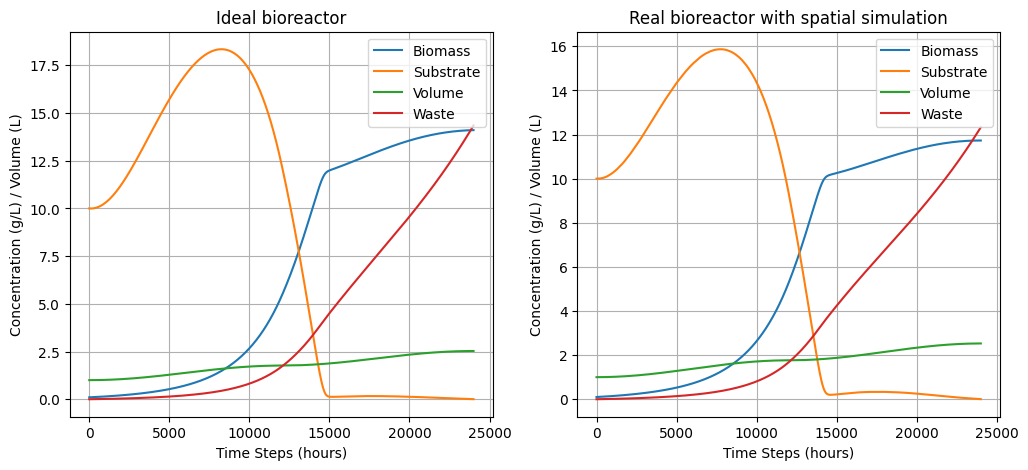

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('Ideal bioreactor')
plt.subplot(1, 2, 2)
plt.plot(true_states_real, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Real bioreactor with spatial simulation')
plt.legend()

Despite the model being imperfect, the EKF is still able to accurately estimate the state of the system, with comparable error than in the first case with the ideal model. The signal is more jittery however.

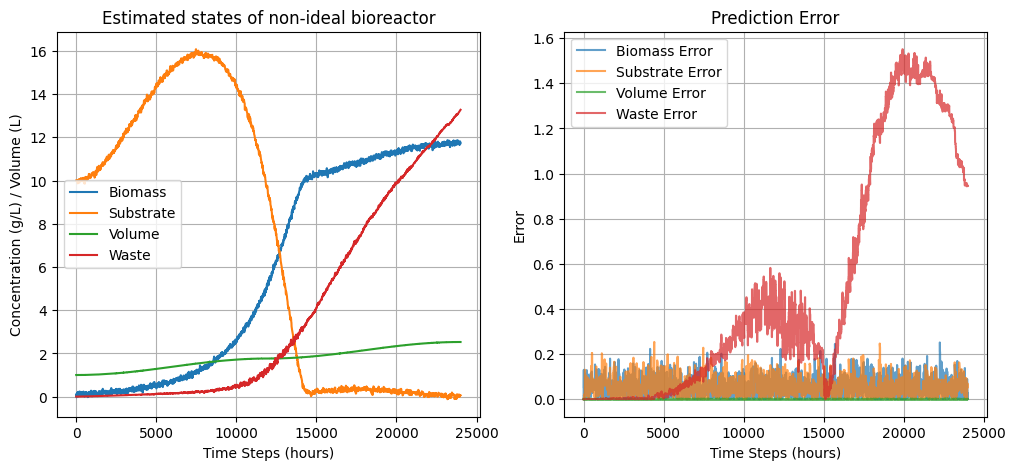

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(estimated_states_real, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('Estimated states of non-ideal bioreactor')
plt.subplot(1, 2, 2)
plt.plot(np.sqrt((true_states_real - estimated_states_real) ** 2), label=['Biomass Error', 'Substrate Error', 'Volume Error', 'Waste Error'], alpha=0.7)
plt.xlabel('Time Steps (hours)')
plt.ylabel('Error')
plt.grid()
plt.title('Prediction Error')
plt.legend()

We try a new bioreactor here. Same model as the real one, but we enhance the stirring speed and we put the intake sources in more strategic spots (around the corners) ( NOT directly on the edge because that creates numerical issues and everything basically explodes)

In [14]:
alt_grid_params = {
            'grid_size': 50,
            'omega': 3.0,
            'alpha': 0.75,
            'Ds': 2e-3,
            'Dw': 1e-3,
            'intake_source' : [[4, 44, 4, 44 ],[4, 4, 44, 44]]
        }

real_bioreactor = real_Bioreactor(bioreactor_params, alt_grid_params)
alt_true_states = []
alt_X_grids = []
alt_S_grids = []
alt_true_states.append(real_bioreactor.state.copy())
alt_X_grids.append(real_bioreactor.X_grid.copy())
alt_S_grids.append(real_bioreactor.S_grid.copy())
for t in range(time_steps):
    F = F_sine(t * dt)
    real_bioreactor.update(F, dt)
    alt_true_states.append(real_bioreactor.state.copy())
    alt_X_grids.append(real_bioreactor.X_grid.copy())
    alt_S_grids.append(real_bioreactor.S_grid.copy())
alt_true_states = np.array(alt_true_states)
alt_history = {'biomass': alt_X_grids, 'substrate': alt_S_grids}

We can see that we can mitigate the local starvation this way, and the model starts behaving a lot like the ideal one

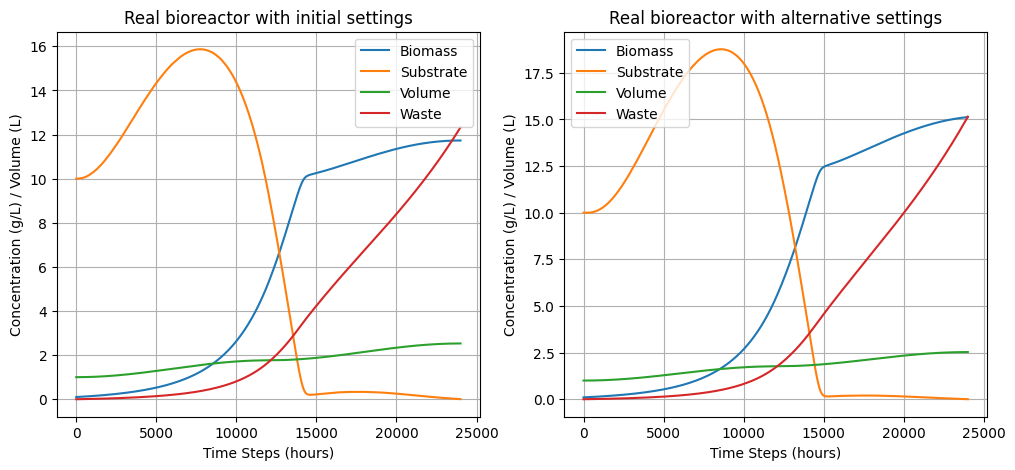

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states_real, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('Real bioreactor with initial settings')
plt.subplot(1, 2, 2)
plt.plot(alt_true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Real bioreactor with alternative settings')
plt.legend()

In [16]:
interactive(plotter, timestep = Play(min=0, max=time_steps, value=0, interval=20),
             history=fixed(alt_history))

interactive(children=(Play(value=0, description='timestep', interval=20, max=24000), Output()), _dom_classes=(…

Another spatial bioreactor, this time with less stirring and just one source placed in the middle, which is possibly the worst spot

In [17]:
alt2_grid_params = {
            'grid_size': 50,
            'omega': 1.0,
            'alpha': 0.5,
            'Ds': 2e-3,
            'Dw': 1e-3,
            'intake_source' : [[24],[24]]
        }

real_bioreactor = real_Bioreactor(bioreactor_params, alt2_grid_params)
ekf = EKF(real_bioreactor, ekf_params)
alt2_true_states = []
alt2_estimated_state = []
alt2_X_grids = []
alt2_S_grids = []
alt2_true_states.append(real_bioreactor.state.copy())
alt2_estimated_state.append(ekf.state.copy())
alt2_X_grids.append(real_bioreactor.X_grid.copy())
alt2_S_grids.append(real_bioreactor.S_grid.copy())
for t in range(time_steps):
    F = F_sine(t * dt)
    real_bioreactor.update(F, dt)
    alt2_true_states.append(real_bioreactor.state.copy())
    alt2_estimated_state.append(ekf.step(F,t, dt))
    alt2_X_grids.append(real_bioreactor.X_grid.copy())
    alt2_S_grids.append(real_bioreactor.S_grid.copy())
alt2_true_states = np.array(alt2_true_states)
alt2_history = {'biomass': alt2_X_grids, 'substrate': alt2_S_grids}

Very significant difference, the substrate concentrations drastically drops due to the big difference in local concentrations

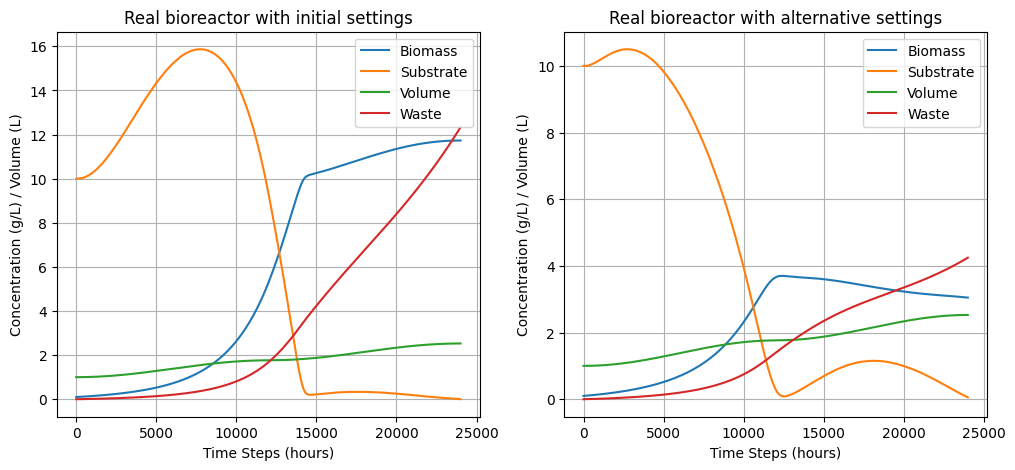

In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states_real, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('Real bioreactor with initial settings')
plt.subplot(1, 2, 2)
plt.plot(alt2_true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Real bioreactor with alternative settings')
plt.legend()

The EKF has to rely on the measurements rather than the model, the signal is very noisy and completely off for the waste (somehow becomes negative)

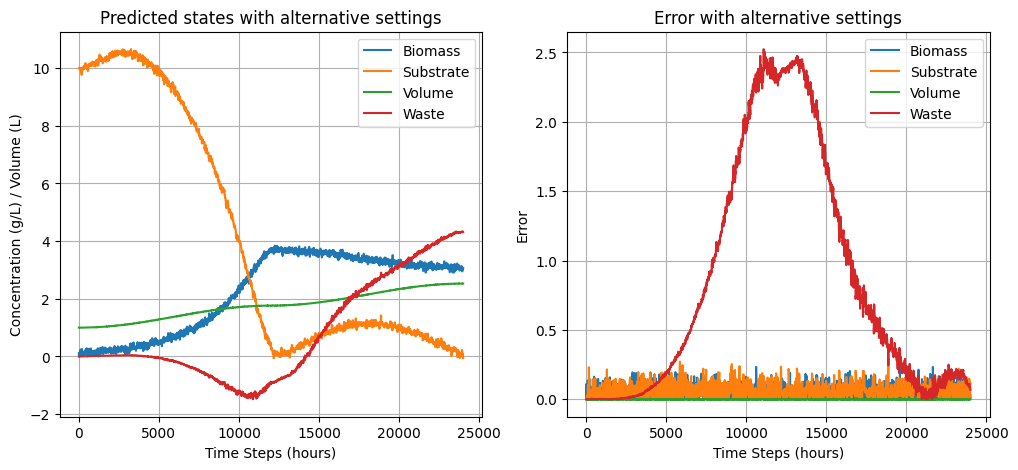

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(alt2_estimated_state, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('Predicted states with alternative settings')
plt.subplot(1, 2, 2)
plt.plot(np.sqrt((alt2_true_states - alt2_estimated_state) ** 2), label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Error')
plt.grid()
plt.title('Error with alternative settings')
plt.legend()

From all that came before, the spatial bioreactor is able to produce results close to the ideal one under certain conditions (strong stirring, strategic intake source spots), in which case the EKF displays good performance for state estimation. That being said, if these conditions are not met, then the local starvation takes over as the substrate cannot properly diffuse throughout the bioreactor. 

In [15]:
bioreactor_params = {
            'initial_biomass_concentration': 0.1,  # g/L
            'initial_substrate_concentration': 0.2,  # g/L
            'initial_volume': 1.0,  # L
            'initial_waste_concentration': 0.0,  # g/L
            'maximum_specific_growth': 0.4,  # 1/h
            'substrate_saturation_constant': 0.5,  # g/L
            'waste_inhibition_constant': 0.05,  # g/L
            'biomass_yield_coefficient': 0.5,  # g biomass / g substrate
            'waste_production_rate': 0.1,  # g waste / g biomass
            'growth_associated_waste_production_rate': 0.05,  # g waste / g biomass
            'capacity': 5.0,  # L
            'inlet_substrate_concentration': 40.0  # g/L
        }

In [16]:
real_bioreactor = real_Bioreactor(bioreactor_params, grid_params)
ekf = EKF(real_bioreactor, ekf_params)
MPC_controller = MPC(real_bioreactor, params.mpc_params)
time_steps = 10000

In [17]:
F_inputs = []
states = []
estimated = []
states.append(real_bioreactor.state.copy())
estimated.append(ekf.state.copy())
for t in range(time_steps):
    F = MPC_controller.optimize(ekf.state, dt)
    real_bioreactor.update(F, dt)
    estimated.append(ekf.step(F,t, dt))
    states.append(real_bioreactor.state.copy())
    F_inputs.append(F)

In [18]:
F_inputs = np.array(F_inputs)
states = np.array(states)
estimated = np.array(estimated)

Text(0.5, 1.0, 'MPC Feed Rate over Time')

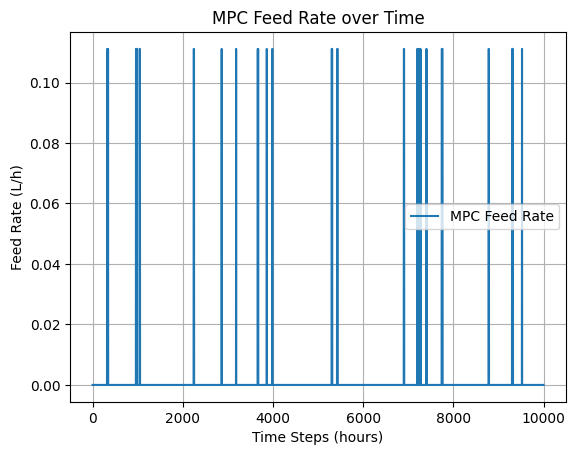

In [19]:
plt.plot(F_inputs, label='MPC Feed Rate')
plt.xlabel('Time Steps (hours)')
plt.ylabel('Feed Rate (L/h)')
plt.grid()
plt.legend()
plt.title('MPC Feed Rate over Time')

Text(0.5, 1.0, 'Bioreactor States over Time')

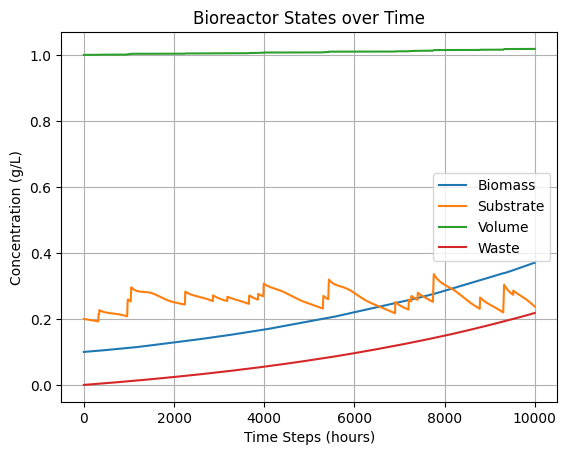

In [20]:
plt.plot(states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L)')
plt.grid()
plt.legend()
plt.title('Bioreactor States over Time')